# LinkedIn Company Analytics: Predictive Modeling and Unsupervised Learning

**Research-oriented analysis of company characteristics, LinkedIn presence, organizational size, and textual information.**

### Research questions

1. How are LinkedIn follower counts distributed across companies?
2. Which observable company attributes are associated with LinkedIn follower counts?
3. How predictable is company size from LinkedIn followers and employee representation?
4. Can companies be grouped into meaningful clusters based on their LinkedIn presence?
5. What information can be extracted from company specialties and slogans?

The notebook emphasizes **reproducibility, model comparison, evaluation, and critical interpretation** rather than maximizing the number of algorithms.


## 1. Imports and reproducibility

A fixed random seed is used for stochastic procedures so that experiments can be reproduced.


In [3]:
import ast
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, silhouette_score
)
from sklearn.cluster import KMeans

from wordcloud import WordCloud
from textblob import TextBlob

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


## 2. Load and inspect the dataset

The dataset contains LinkedIn company profiles with organizational, geographic, funding, and textual attributes.


In [4]:
DATA_PATH = r"/content/LinkedIn-company-info.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (1000, 30)


,id,name,country_code,locations,followers,employees_in_linkedin,about,specialties,company_size,organization_type,...,url,updates,slogan,affiliated,funding,investors,formatted_locations,stock_info,get_directions_url,description
0,fleak,Fleak,US,"[""San Jose, US""]",312,11,Fleak unblocks your data team from batch proce...,"APIs, Microservices, Serverless, Data Pipeline...",2-10 employees,Privately Held,...,https://www.linkedin.com/company/fleak,"[{""comments_count"":1,""likes_count"":3,""post_id""...",AI Workflows. Simplified.,NaN,"{""last_round_date"":""2024-05-01T00:00:00.000Z"",...","[""CoreNest Capital""]","[""San Jose, US""]",NaN,"[{""directions_url"":""https://www.bing.com/maps?...",Fleak | 312 followers on LinkedIn. AI Workflow...
1,balance-cash,Balance,US,"[""Denver, CO 80224, US""]",235,3,Balance is financial forecasting for the indep...,"Financial Forecasting, Money Management, Indep...",2-10 employees,Privately Held,...,https://www.linkedin.com/company/balance-cash,"[{""images"":[""https://media.licdn.com/dms/image...",Independent workers take a different view of t...,NaN,"{""last_round_date"":""2023-09-15T00:00:00.000Z"",...","[""Techstars""]","[""Denver, CO 80224, US""]",NaN,"[{""directions_url"":""https://www.bing.com/maps?...",Balance | 235 followers on LinkedIn. Independe...
2,ergotech-systems-inc-,"ErgoTech Systems, Inc.",US,"[""190 Central Park Square Los Alamos, NM 87544...",126,4,ErgoTech develops and sells factory automation...,Industrial Automation and Semiconductor,2-10 employees,Privately Held,...,https://www.linkedin.com/company/ergotech-syst...,"[{""external_link"":""https://www.linkedin.com/re...",Data Collection ○ Analytics ○ AI ○ Cloud ○ IOT...,NaN,"{""last_round_date"":""2023-02-24T00:00:00.000Z"",...","[""Small Business Innovation Research""]","[""190 Central Park Square, Los Alamos, NM 8754...",NaN,"[{""directions_url"":""https://www.bing.com/maps?...","ErgoTech Systems, Inc. | 126 followers on Link..."
3,clubready,"ClubReady, LLC",US,"[""14515 North Outer Forty Suite 300 Chesterfie...",2652,109,ClubReady is a web-based fitness management pl...,"Member Management, Billing, HealthClub Managem...",51-200 employees,Privately Held,...,https://www.linkedin.com/company/clubready,"[{""external_link"":""https://www.linkedin.com/re...",Build Your Fitness Business for the Future,NaN,"{""last_round_date"":""2016-04-22T00:00:00.000Z"",...","[""Level Equity Management""]","[""14515 North Outer Forty, Suite 300, Chesterf...",NaN,"[{""directions_url"":""https://www.bing.com/maps?...","ClubReady, LLC | 2,652 followers on LinkedIn. ..."
4,ewa,Electronic Warfare Associates (EWA),US,"[""13873 Park Center Rd 5th Floor Herndon, VIRG...",5089,315,"EWA is a veteran-owned, small broad-based tech...","Counter-UAS Technologies, Cyber Operations and...",201-500 employees,Privately Held,...,https://www.linkedin.com/company/ewa,"[{""external_link"":""https://www.linkedin.com/re...",Enabling a More Secure Future,"[{""Links"":""https://www.linkedin.com/company/ew...","{""last_round_date"":""2015-06-11T00:00:00.000Z"",...","[""American Capital""]","[""13873 Park Center Rd, 5th Floor, Herndon, VI...",NaN,"[{""directions_url"":""https://www.bing.com/maps?...","Electronic Warfare Associates (EWA) | 5,089 fo..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1000 non-null   object 
 1   name                   1000 non-null   object 
 2   country_code           1000 non-null   object 
 3   locations              1000 non-null   object 
 4   followers              1000 non-null   int64  
 5   employees_in_linkedin  1000 non-null   int64  
 6   about                  1000 non-null   object 
 7   specialties            976 non-null    object 
 8   company_size           1000 non-null   object 
 9   organization_type      1000 non-null   object 
 10  industries             1000 non-null   object 
 11  website                1000 non-null   object 
 12  crunchbase_url         1000 non-null   object 
 13  founded                937 non-null    float64
 14  company_id             1000 non-null   int64  
 15  emplo

None

## 3. Data quality and preprocessing

Missing values are inspected before modeling. Numerical missingness is **not** automatically replaced by zero because zero and missing have different meanings. Model pipelines handle numerical and categorical missing values explicitly.


In [5]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)
missing["missing_pct"] = 100 * missing["missing_count"] / len(df)
display(missing[missing["missing_count"] > 0].head(20))

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().copy()
print("Shape after duplicate removal:", df.shape)

,missing_count,missing_pct
stock_info,840,84.0
affiliated,626,62.6
investors,188,18.8
founded,63,6.3
slogan,37,3.7
specialties,24,2.4
similar,6,0.6
updates,3,0.3


Duplicate rows: 0
Shape after duplicate removal: (1000, 30)


## 4. Feature engineering

The original dataset stores several fields in semi-structured formats. We extract interpretable numerical features while retaining the original information for later analysis.

For follower counts, `log1p` is used because social-media audience sizes are typically heavily right-skewed.


In [6]:
def extract_first_value(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list) and parsed:
            item = parsed[0]
            if isinstance(item, dict):
                return item.get("value") or item.get("name") or item.get("location")
            return item
        if isinstance(parsed, dict):
            return parsed.get("value") or parsed.get("name") or parsed.get("location")
    except (ValueError, SyntaxError):
        pass
    return text

# Numeric conversion
for col in ["followers", "employees_in_linkedin", "founded"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Company age relative to 2025 (the dataset publication context)
df["company_age"] = np.where(
    df["founded"].notna() & (df["founded"] > 0) & (df["founded"] <= 2025),
    2025 - df["founded"],
    np.nan
)

# Log transform for skewed follower counts
df["log_followers"] = np.log1p(df["followers"].clip(lower=0))

# Location extraction where available
if "locations" in df.columns:
    df["main_location"] = df["locations"].apply(extract_first_value)

display(df[["followers", "log_followers", "employees_in_linkedin", "founded", "company_age"]].describe())

,followers,log_followers,employees_in_linkedin,founded,company_age
count,1.000000e+03,1000.000000,1000.000000,937.000000,937.000000
mean,2.051252e+05,9.591280,6236.469000,2003.811099,21.188901
std,8.289618e+05,2.333444,25289.730705,27.852664,27.852664
min,1.400000e+01,2.708050,1.000000,1812.000000,1.000000
25%,2.815250e+03,7.943157,39.000000,2003.000000,7.000000
50%,1.194350e+04,9.388023,150.000000,2013.000000,12.000000
75%,6.835175e+04,11.132437,1009.750000,2018.000000,22.000000
max,1.205058e+07,16.304624,473210.000000,2024.000000,213.000000


## 5. Exploratory data analysis

### Follower distribution

Follower counts are visualized on both the original and logarithmic scales to make the effect of skewness explicit.


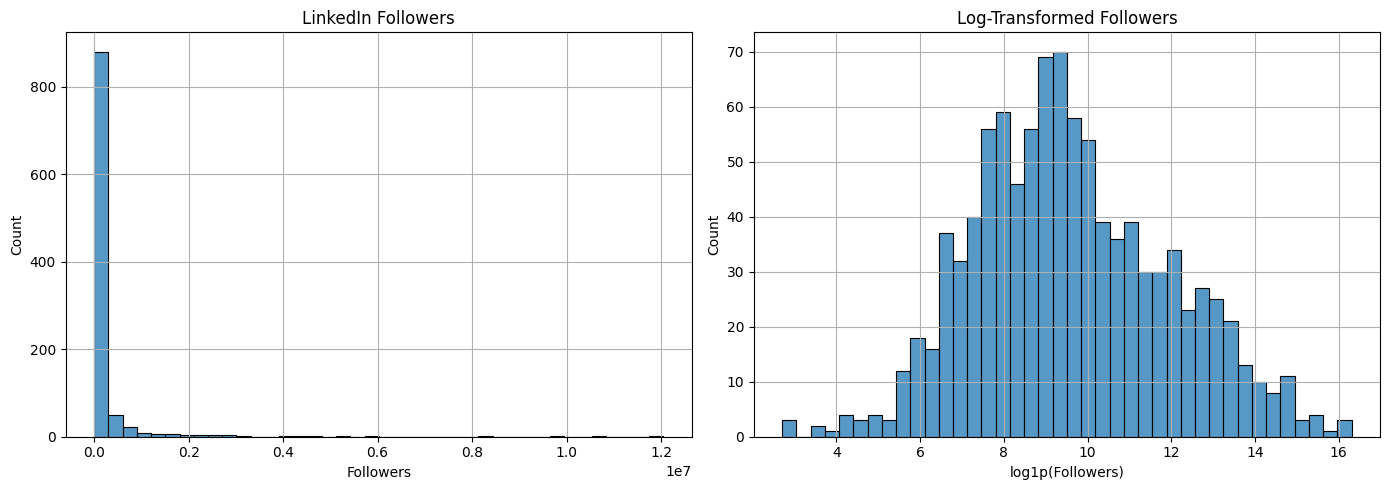

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["followers"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("LinkedIn Followers")
axes[0].set_xlabel("Followers")

sns.histplot(df["log_followers"].dropna(), bins=40, ax=axes[1])
axes[1].set_title("Log-Transformed Followers")
axes[1].set_xlabel("log1p(Followers)")

plt.tight_layout()

plt.savefig('Log_Transformed_Followers.png',dpi=300,bbox_inches='tight')
plt.show()

### Relationships between numerical variables

Both Pearson and Spearman correlations are useful here. Pearson measures linear association, while Spearman is more robust to non-normality and monotonic relationships.


,followers,log_followers,employees_in_linkedin,founded,company_age
followers,1.000,0.496,0.635,-0.236,0.236
log_followers,0.496,1.000,0.462,-0.422,0.422
employees_in_linkedin,0.635,0.462,1.000,-0.357,0.357
founded,-0.236,-0.422,-0.357,1.000,-1.000
company_age,0.236,0.422,0.357,-1.000,1.000


,followers,log_followers,employees_in_linkedin,founded,company_age
followers,1.000,1.000,0.899,-0.486,0.486
log_followers,1.000,1.000,0.899,-0.486,0.486
employees_in_linkedin,0.899,0.899,1.000,-0.601,0.601
founded,-0.486,-0.486,-0.601,1.000,-1.000
company_age,0.486,0.486,0.601,-1.000,1.000


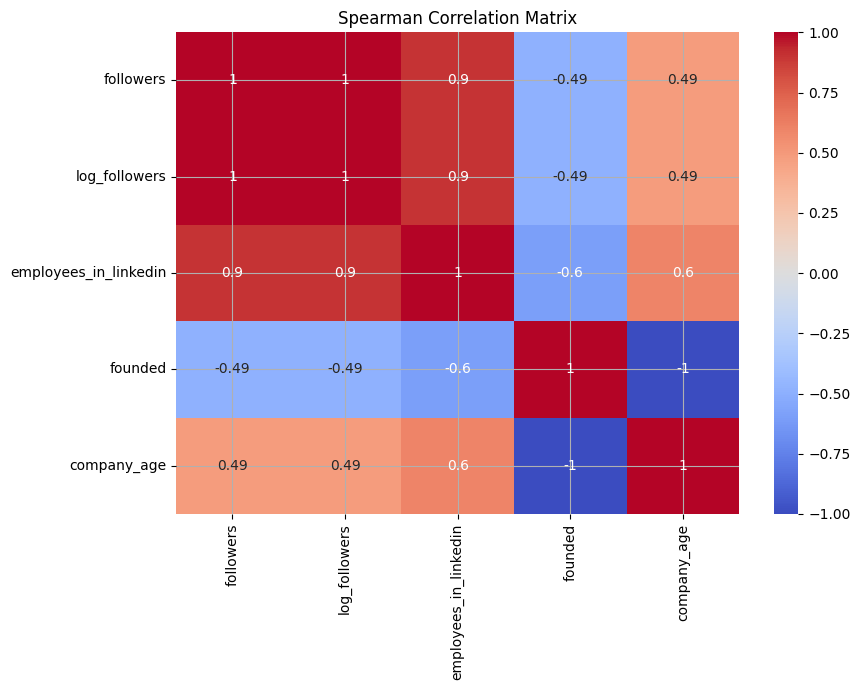

In [8]:
numeric_cols = [
    c for c in ["followers", "log_followers", "employees_in_linkedin",
                "founded", "company_age"]
    if c in df.columns
]

display(df[numeric_cols].corr(method="pearson").round(3))
display(df[numeric_cols].corr(method="spearman").round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(method="spearman"), annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()

plt.savefig('Spearman Correlation Matrix.png',dpi=300,bbox_inches='tight')
plt.show()

### Company-size distribution

LinkedIn's original company-size ranges are mapped into broader categories. The mapping is explicit so that the target variable is reproducible.


,count
size_category,
Medium,461
Large,201
Very Large,129
Unknown,116
Small,93


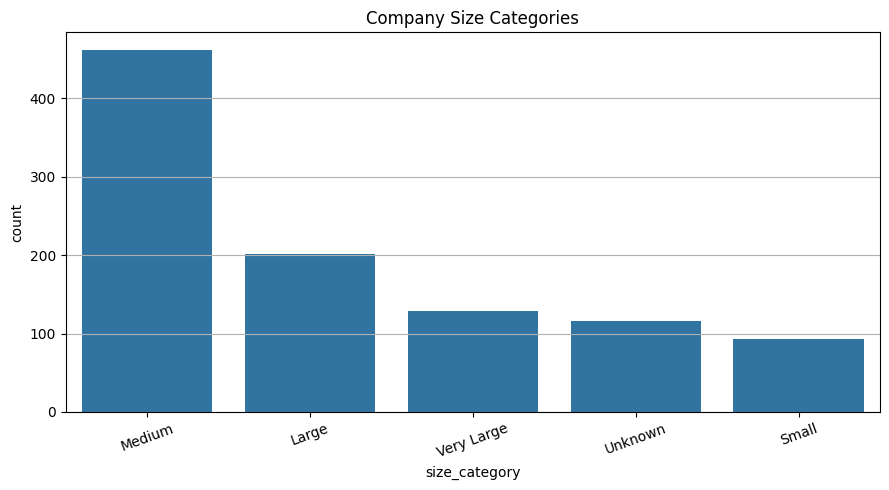

In [9]:
def categorize_size(value):
    if pd.isna(value):
        return "Unknown"

    s = str(value).strip().lower()

    if "self-employed" in s or "1 employee" in s or "2-10" in s:
        return "Small"
    if "11-50" in s or "51-200" in s:
        return "Medium"
    if "201-500" in s or "501-1,000" in s or "1001-5000" in s:
        return "Large"
    if "5001-10,000" in s or "10,001+" in s or "10001" in s:
        return "Very Large"
    return "Unknown"

if "company_size" in df.columns:
    df["size_category"] = df["company_size"].apply(categorize_size)
elif "size" in df.columns:
    df["size_category"] = df["size"].apply(categorize_size)

display(df["size_category"].value_counts(dropna=False))

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="size_category", order=df["size_category"].value_counts().index)
plt.title("Company Size Categories")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig('Company Size Categories.png',dpi=300,bbox_inches='tight')
plt.show()

## 6. Follower prediction

### Research question

> To what extent can LinkedIn follower counts be explained by observable company characteristics?

Because follower counts are highly skewed, the target is modeled as `log1p(followers)`.

Two models are compared:

- Linear Regression — interpretable baseline
- Random Forest Regressor — nonlinear benchmark

A median predictor is included as a naive baseline.


In [10]:
reg_features = [c for c in ["employees_in_linkedin", "company_age"] if c in df.columns]

reg_df = df[reg_features + ["log_followers", "followers"]].dropna(subset=["log_followers"]).copy()

X = reg_df[reg_features]
y = reg_df["log_followers"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        min_samples_leaf=3,
        n_jobs=-1
    ))
])

models = {
    "Median baseline": None,
    "Linear Regression": linear_model,
    "Random Forest": rf_model
}

reg_results = []

baseline_pred = np.repeat(y_train.median(), len(y_test))
reg_results.append({
    "Model": "Median baseline",
    "MAE": mean_absolute_error(y_test, baseline_pred),
    "RMSE": mean_squared_error(y_test, baseline_pred) ** 0.5,
    "R2": r2_score(y_test, baseline_pred)
})

predictions = {}

for name, model in list(models.items())[1:]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("RMSE")
display(reg_results_df.round(4))

,Model,MAE,RMSE,R2
2,Random Forest,0.7606,0.9911,0.8023
0,Median baseline,1.7657,2.3187,-0.0822
1,Linear Regression,1.5125,2.3923,-0.1519


### Regression diagnostics

The residual plot helps determine whether systematic patterns remain unexplained by the models.


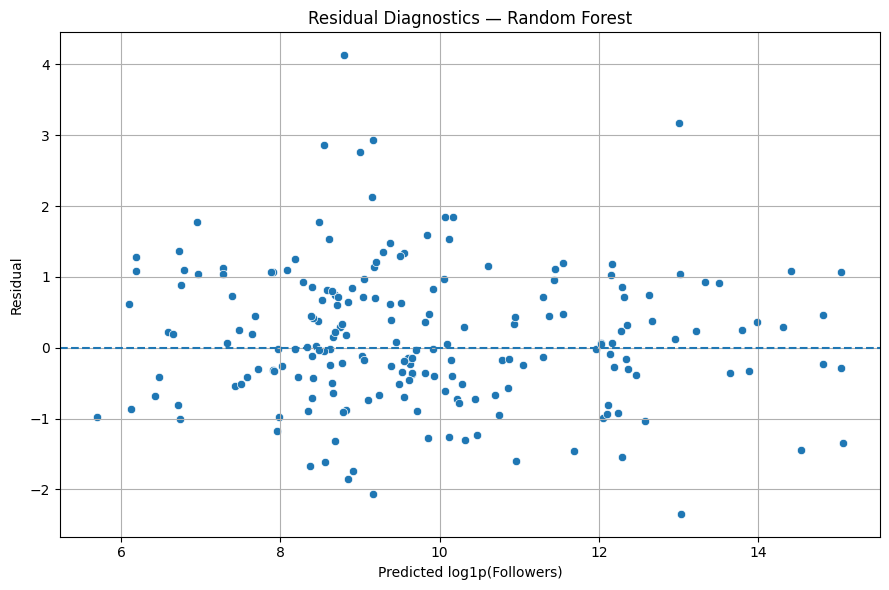

In [11]:
best_reg_name = reg_results_df.iloc[0]["Model"]

if best_reg_name != "Median baseline":
    best_pred = predictions[best_reg_name]
    residuals = y_test - best_pred

    plt.figure(figsize=(9, 6))
    sns.scatterplot(x=best_pred, y=residuals)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted log1p(Followers)")
    plt.ylabel("Residual")
    plt.title(f"Residual Diagnostics — {best_reg_name}")
    plt.tight_layout()

    plt.savefig('Residual_Diagnostics_RF.png',dpi=300,bbox_inches='tight')
    plt.show()

## 7. Company-size classification

### Research question

> Can company size be inferred from observable LinkedIn presence?

The classification task uses:

- LinkedIn followers
- Employees represented on LinkedIn

A stratified split preserves the class distribution between training and test sets.

Models:

- Logistic Regression — interpretable linear baseline
- Random Forest — nonlinear benchmark


In [12]:
clf_features = [c for c in ["followers", "employees_in_linkedin"] if c in df.columns]

clf_df = df[clf_features + ["size_category"]].dropna(subset=["size_category"]).copy()
clf_df = clf_df[clf_df["size_category"] != "Unknown"].copy()

# Remove classes with too few examples for a stratified split
class_counts = clf_df["size_category"].value_counts()
valid_classes = class_counts[class_counts >= 5].index
clf_df = clf_df[clf_df["size_category"].isin(valid_classes)].copy()

X = clf_df[clf_features]
y = clf_df["size_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

rf_classifier = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1
    ))
])

clf_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_classifier
}

clf_results = []
clf_predictions = {}

for name, model in clf_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    clf_predictions[name] = pred

    clf_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1": f1_score(y_test, pred, average="weighted", zero_division=0)
    })

clf_results_df = pd.DataFrame(clf_results).sort_values("F1", ascending=False)
display(clf_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1
1,Random Forest,0.791,0.7911,0.791,0.7910
0,Logistic Regression,0.678,0.6938,0.678,0.5724


### Classification report and confusion matrix


              precision    recall  f1-score   support

       Large       0.78      0.80      0.79        40
      Medium       0.80      0.79      0.80        92
       Small       0.47      0.47      0.47        19
  Very Large       1.00      1.00      1.00        26

    accuracy                           0.79       177
   macro avg       0.76      0.77      0.77       177
weighted avg       0.79      0.79      0.79       177



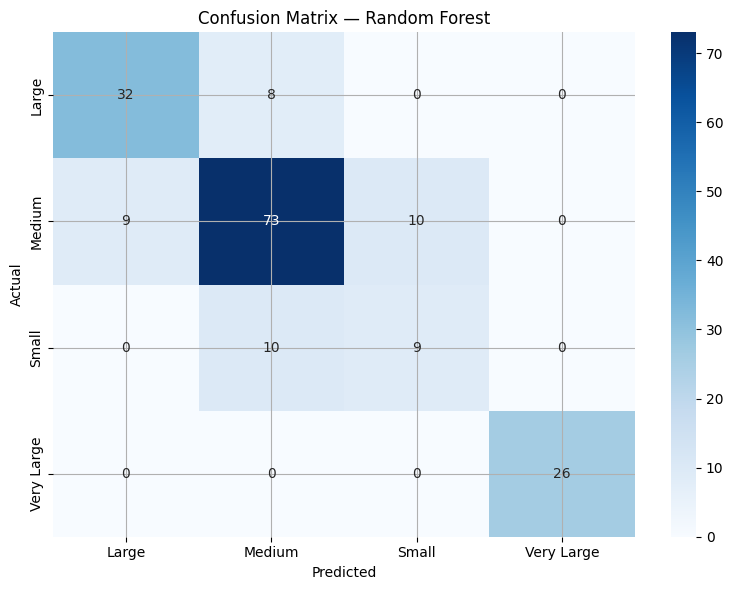

In [13]:
best_clf_name = clf_results_df.iloc[0]["Model"]
best_clf_pred = clf_predictions[best_clf_name]

print(classification_report(y_test, best_clf_pred, zero_division=0))

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_clf_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_clf_name}")
plt.tight_layout()
plt.savefig('Confusion_Matrix_RF.png',dpi=300,bbox_inches='tight')
plt.show()

## 8. Unsupervised learning: company clustering

Rather than choosing three clusters arbitrarily, several values of `k` are evaluated using the silhouette score.

The clustering variables are log-transformed followers and log-transformed LinkedIn employee counts to reduce the influence of extreme observations.


,k,silhouette_score
0,2,0.5643
1,3,0.4971
2,4,0.4439
3,5,0.4243
4,6,0.3925
5,7,0.3762
6,8,0.3569


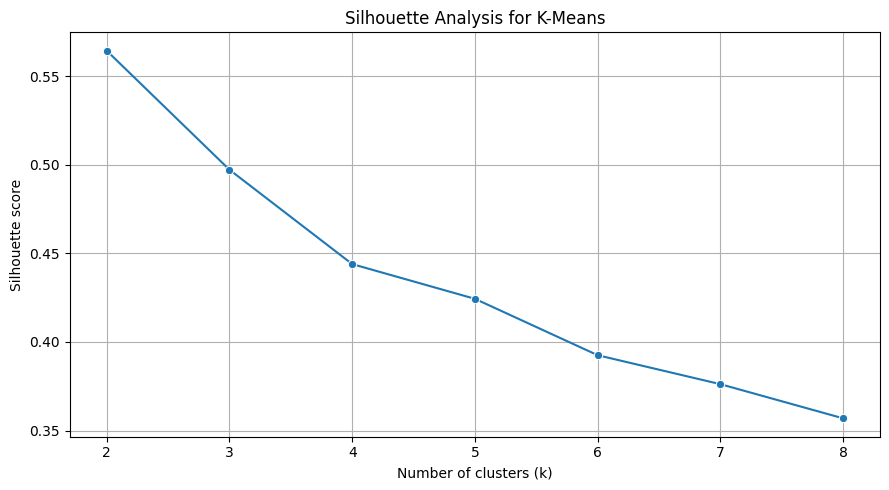

Selected k: 2


In [15]:
cluster_features = df[["followers", "employees_in_linkedin"]].copy()
cluster_features["followers"] = np.log1p(cluster_features["followers"].clip(lower=0))
cluster_features["employees_in_linkedin"] = np.log1p(
    cluster_features["employees_in_linkedin"].clip(lower=0)
)
cluster_features = cluster_features.fillna(cluster_features.median())

cluster_scaled = StandardScaler().fit_transform(cluster_features)

scores = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels_k = km.fit_predict(cluster_scaled)
    scores.append({
        "k": k,
        "silhouette_score": silhouette_score(cluster_scaled, labels_k)
    })

silhouette_df = pd.DataFrame(scores)
display(silhouette_df.round(4))

plt.figure(figsize=(9, 5))
sns.lineplot(data=silhouette_df, x="k", y="silhouette_score", marker="o")
plt.title("Silhouette Analysis for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.tight_layout()

plt.title("Silhouette Analysis for K-Means")
plt.savefig('Silhouette Analysis for K-Means.png',dpi=300,bbox_inches='tight')
plt.show()

best_k = int(silhouette_df.loc[silhouette_df["silhouette_score"].idxmax(), "k"])
print("Selected k:", best_k)

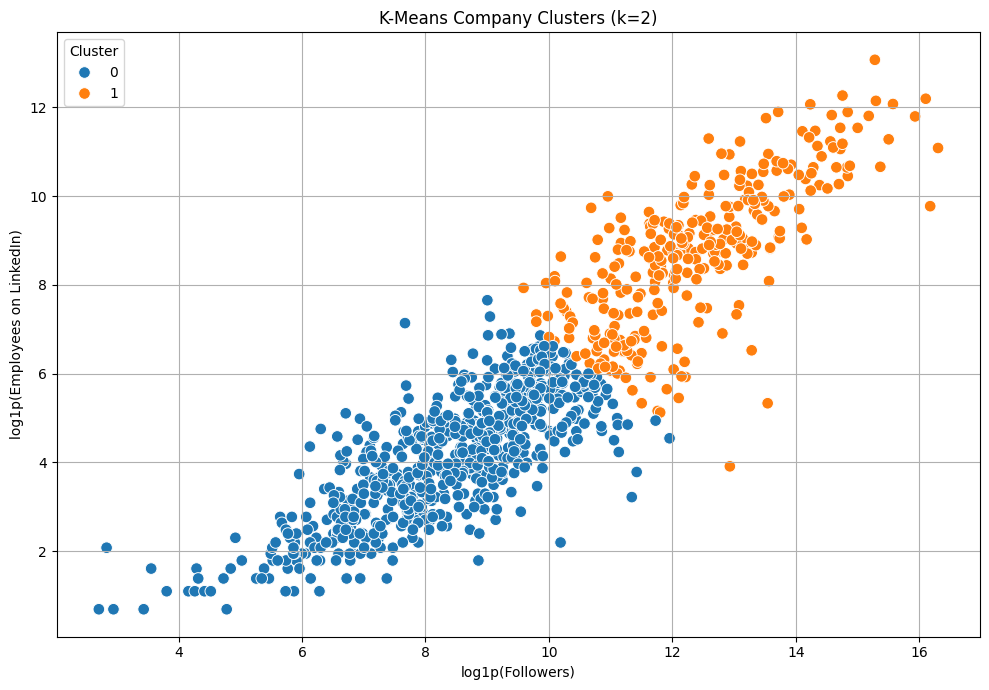

followers                          employees_in_linkedin          \
            count    median           mean                 count  median   
cluster                                                                    
0             695    5221.0   10064.279137                   695    69.0   
1             305  194860.0  649608.357377                   305  6490.0   

                       
                 mean  
cluster                
0          140.520863  
1        20127.236066

In [16]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(cluster_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=cluster_features["followers"],
    y=cluster_features["employees_in_linkedin"],
    hue=df["cluster"],
    palette="tab10",
    s=70
)
plt.xlabel("log1p(Followers)")
plt.ylabel("log1p(Employees on LinkedIn)")
plt.title(f"K-Means Company Clusters (k={best_k})")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig('K-Means Company Clusters.png',dpi=300,bbox_inches='tight')
plt.show()

cluster_summary = (
    df.groupby("cluster")[["followers", "employees_in_linkedin"]]
      .agg(["count", "median", "mean"])
)

display(cluster_summary)

## 9. NLP: company specialties

Specialties provide a compact description of the technologies, services, and domains associated with each company.

A WordCloud gives a qualitative overview. For a more quantitative extension, TF-IDF or transformer-based embeddings could be used in future work.


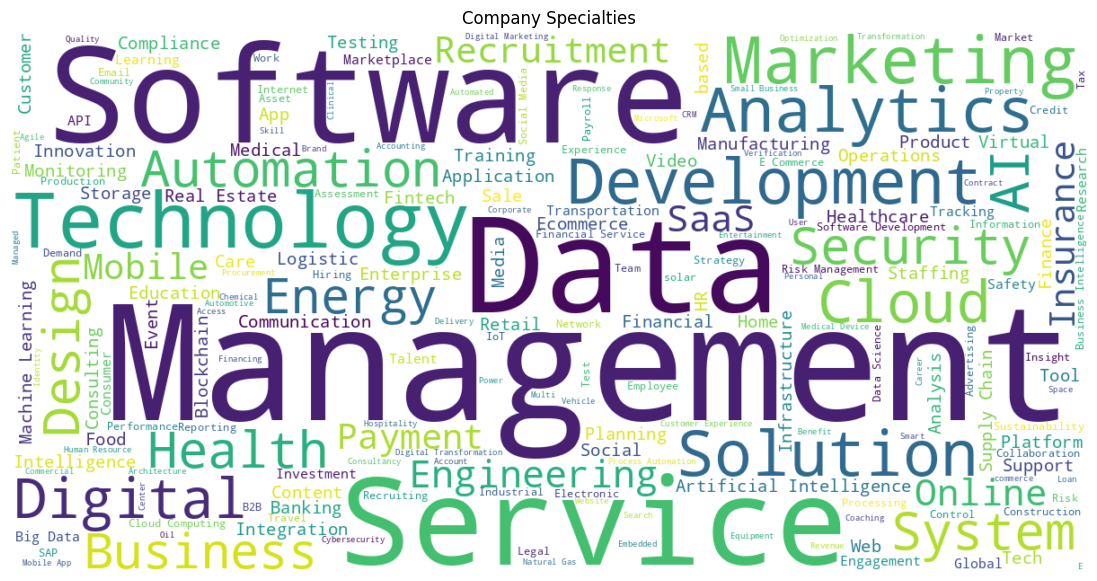

In [17]:
if "specialties" in df.columns:
    specialties = (
        df["specialties"]
        .dropna()
        .astype(str)
        .str.replace(r"[^A-Za-z0-9,;\- ]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    corpus = " ".join(specialties.tolist())

    if corpus.strip():
        wordcloud = WordCloud(
            width=1200,
            height=600,
            background_color="white",
            random_state=RANDOM_STATE
        ).generate(corpus)

        plt.figure(figsize=(14, 7))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title("Company Specialties")
        plt.savefig('Company Specialties.png',dpi=300,bbox_inches='tight')
        plt.show()

## 10. NLP: slogan sentiment

TextBlob polarity is used as a lightweight baseline for slogan sentiment.

**Important limitation:** short marketing slogans are context-dependent, and lexicon-based sentiment scores should not be interpreted as a definitive measure of corporate sentiment.


,count
sentiment,
Neutral,601
Positive,336
Negative,63


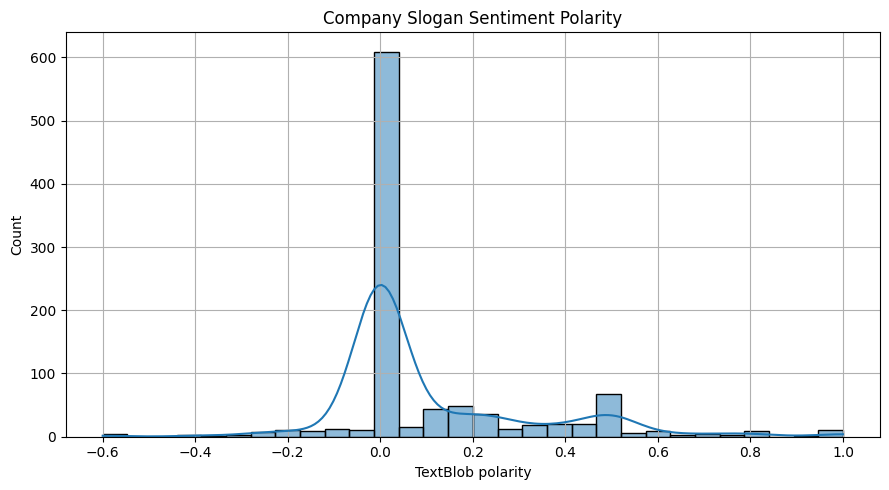

In [18]:
if "slogan" in df.columns:
    sentiment_df = df[["slogan"]].copy()
    sentiment_df["slogan"] = sentiment_df["slogan"].fillna("").astype(str)
    sentiment_df["polarity"] = sentiment_df["slogan"].apply(
        lambda x: TextBlob(x).sentiment.polarity
    )

    sentiment_df["sentiment"] = pd.cut(
        sentiment_df["polarity"],
        bins=[-1, -1e-9, 1e-9, 1],
        labels=["Negative", "Neutral", "Positive"]
    )

    display(sentiment_df["sentiment"].value_counts())

    plt.figure(figsize=(9, 5))
    sns.histplot(sentiment_df["polarity"], bins=30, kde=True)
    plt.title("Company Slogan Sentiment Polarity")
    plt.xlabel("TextBlob polarity")
    plt.tight_layout()
    plt.savefig('Company Slogan Sentiment Polarity.png',dpi=300,bbox_inches='tight')
    plt.show()

## 11. Interpretation and limitations

### Main observations

- LinkedIn follower counts are highly skewed, motivating logarithmic transformation.
- Company size is substantially more predictable from follower and employee counts than follower volume alone is from a small set of company attributes.
- Nonlinear models provide a useful benchmark against simpler linear/logistic baselines.
- Clustering results should be interpreted as patterns in LinkedIn presence rather than definitive business categories.
- Slogan sentiment and WordCloud results are exploratory NLP analyses rather than robust semantic understanding.

### Limitations

1. The dataset contains approximately 1,000 company profiles and may not represent all companies or industries.
2. LinkedIn follower counts and employee counts are observational snapshots rather than controlled measurements.
3. The follower regression uses a limited feature set.
4. Company-size labels are derived from LinkedIn ranges and simplified into broader categories.
5. Random train/test evaluation does not establish causal relationships.
6. TextBlob sentiment is a simple baseline and may miss context, sarcasm, domain-specific language, and nuanced meaning.

### Research extensions

Future work could investigate:

- Gradient boosting and XGBoost for nonlinear prediction.
- Cross-validation and hyperparameter optimization.
- SHAP-based model interpretation.
- Robust regression and quantile regression for follower counts.
- TF-IDF and transformer embeddings for company descriptions/specialties.
- Temporal data collection to study changes in company LinkedIn presence.
- Causal or quasi-experimental questions around funding and organizational growth.


## 12. Reproducibility

The analysis uses a fixed random seed and explicit preprocessing/model pipelines.

Recommended environment:

```text
numpy
pandas
matplotlib
seaborn
scikit-learn
wordcloud
textblob
jupyter
```

The notebook should be executed from top to bottom after updating `DATA_PATH` if the dataset is moved.
